# Mini-Projet : Planification Robuste sur Grille
## A* + Chaînes de Markov à Temps Discret

**Objectif :** Planifier un chemin optimal (A*) sur une grille 2D avec obstacles,
puis évaluer la robustesse du plan sous incertitude stochastique (Chaînes de Markov).

| Phase | Description |
|-------|-------------|
| **E1** | UCS / Greedy / A* sur 3 grilles |
| **E2** | Impact de ε sur P(GOAL) |
| **E3** | h=0 vs Manhattan |
| **E4** | Weighted A* |
| **P3** | Matrice P & évolution π⁽ⁿ⁾ |
| **P4** | Classes, absorption |
| **P5** | Monte Carlo & validation |

All figures and CSV/JSON results are auto-saved to `results/` when running `src/experiments.py`.


In [ ]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings; warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath("../src"))

from grid   import make_easy_grid, make_medium_grid, make_hard_grid
from astar  import graph_search
from markov import (generate_policy, build_transition_matrix, communication_classes, calculate_expected_time, absorption_probabilities, simulate_monte_carlo)

RESULTS = os.path.abspath("../results")
print("Modules loaded. Results will be read from:", RESULTS)


Modules loaded. Results will be read from: c:\Users\Achraf El Makaoui\Desktop\Mini_Projet_Bases_IA - Copie\results


In [11]:
def draw_grid_path(ax, env, path, title, path2=None,
                   color1="royalblue", color2="tomato"):
    W, H = env.width, env.height
    img = np.zeros((H, W))
    for (x, y) in env.obstacles:
        img[y][x] = 1
    cmap = ListedColormap(["#f5f5f5", "#2d2d2d"])
    ax.imshow(img, cmap=cmap, origin="upper", vmin=0, vmax=1)
    def _plot(p, col, lbl, ls="-"):
        if p:
            ax.plot([n[0] for n in p], [n[1] for n in p],
                    color=col, linewidth=2, linestyle=ls,
                    marker=".", markersize=4, label=lbl, zorder=3)
    _plot(path, color1, "A* path")
    if path2:
        _plot(path2, color2, "UCS path", ls="--")
    ax.plot(env.start[0], env.start[1], "go", markersize=9,  zorder=5, label="Start")
    ax.plot(env.goal[0],  env.goal[1],  "r*", markersize=11, zorder=5, label="Goal")
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7, loc="upper right")

print("Helper ready.")


Helper ready.


## E1 — UCS vs Greedy vs A* on 3 grids

Metrics: path cost, nodes developed, max OPEN size, execution time.


Grid             Algo       Cost    Nodes  OPEN_max   Time(ms)
--------------------------------------------------------------
Easy (10x10)     UCS          18       78         8      3.45
Easy (10x10)     Greedy       18       19        17      1.85
Easy (10x10)     A*           18       58         7      1.15

Medium (15x15)   UCS          44      203         8      1.89
Medium (15x15)   Greedy       50       99        33      0.95
Medium (15x15)   A*           44      176        14      0.67

Hard (20x20)     UCS          44      288        17      2.40
Hard (20x20)     Greedy       48      129        50      1.14
Hard (20x20)     A*           44      219        20      1.87



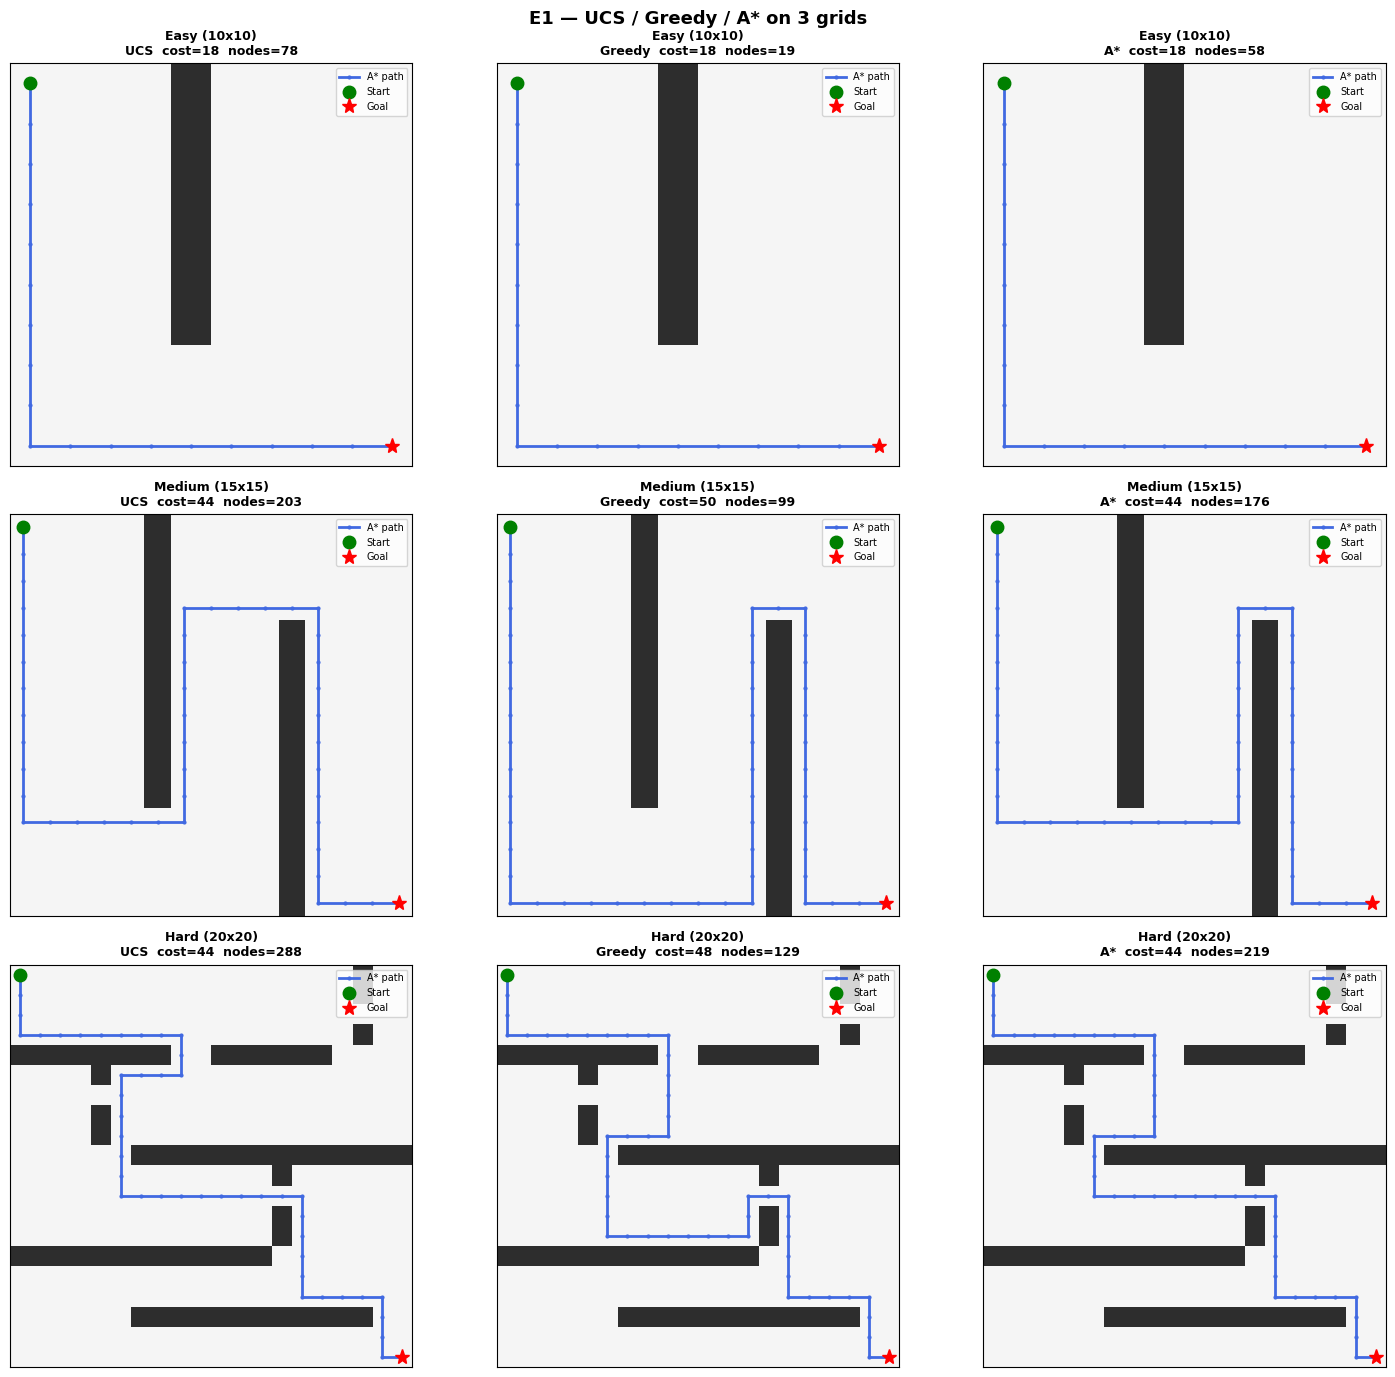

In [12]:
envs  = [("Easy (10x10)",   make_easy_grid()),
         ("Medium (15x15)", make_medium_grid()),
         ("Hard (20x20)",   make_hard_grid())]
modes = ["UCS", "Greedy", "A*"]

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
fig.suptitle("E1 — UCS / Greedy / A* on 3 grids", fontsize=13, fontweight="bold")

print("{:<16} {:<8} {:>6} {:>8} {:>9} {:>10}".format(
    "Grid","Algo","Cost","Nodes","OPEN_max","Time(ms)"))
print("-"*62)

for gi, (name, env) in enumerate(envs):
    for mi, mode in enumerate(modes):
        r = graph_search(env, search_type=mode)
        found = r["path"] is not None
        print("{:<16} {:<8} {:>6.0f} {:>8} {:>9} {:>9.2f}".format(
            name, mode, r["cost"], r["nodes_developed"],
            r["max_open_size"], r["time"]*1000))
        t = name+"\n"+mode+"  cost="+str(int(r["cost"]))+"  nodes="+str(r["nodes_developed"])
        draw_grid_path(axes[gi][mi], env, r["path"] if found else [], t)
    print()

plt.tight_layout()
plt.show()


## E2 — Impact of ε on P(GOAL)

Markov matrix π⁽ⁿ⁾ = π⁽⁰⁾·Pⁿ vs 8000 Monte Carlo trajectories.


A* cost: 44
  eps   P(GOAL) Markov   P(GOAL) MC    Avg steps MC
----------------------------------------------------
  0.0           1.0000       1.0000           44.00
  0.1           0.0334       0.7492           49.43
  0.2           0.0007       0.6706           61.87
  0.3           0.0000       0.6941           84.31


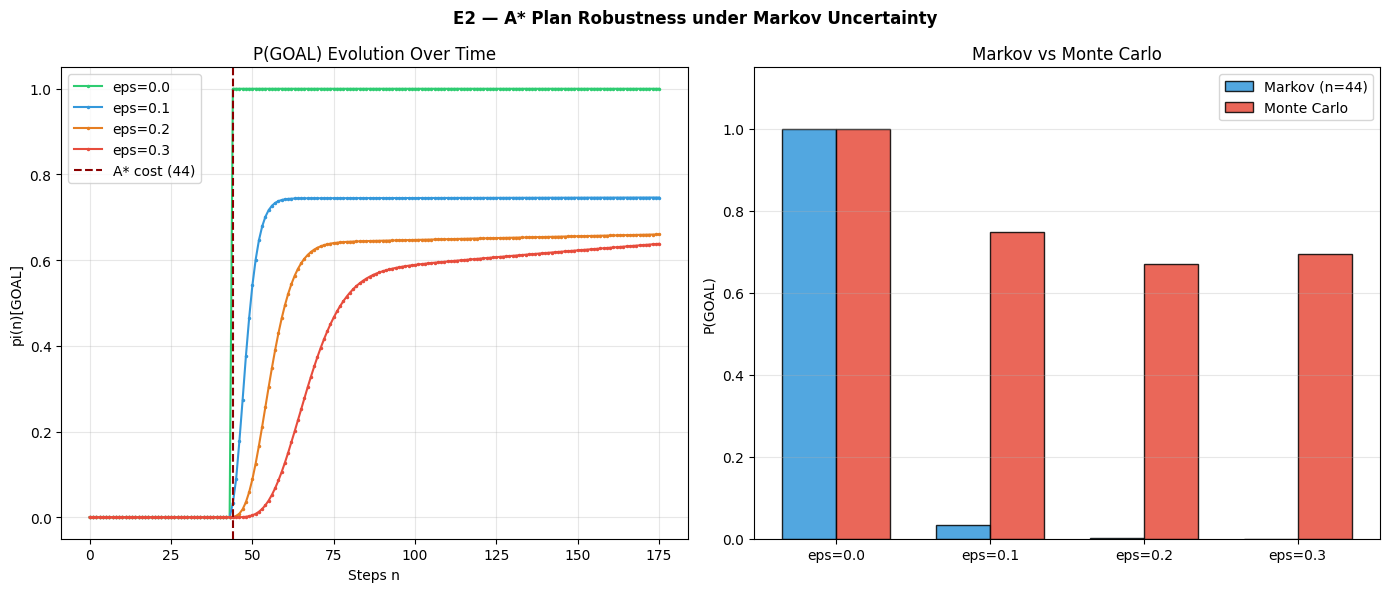

In [13]:
env = make_medium_grid()
res = graph_search(env, search_type="A*")
policy = generate_policy(res["path"], env)
opt = res["cost"]
print("A* cost:", opt)

epsilons = [0.0, 0.1, 0.2, 0.3]
n_range  = range(0, opt * 4)
pal      = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("E2 — A* Plan Robustness under Markov Uncertainty", fontsize=12, fontweight="bold")

print("{:>5} {:>16} {:>12} {:>15}".format("eps","P(GOAL) Markov","P(GOAL) MC","Avg steps MC"))
print("-"*52)

prob_at_opt, prob_mc = [], []
for eps, col in zip(epsilons, pal):
    P, states, s2i = build_transition_matrix(env, policy, epsilon=eps)
    pi0 = np.zeros(len(states))
    pi0[s2i[env.start]] = 1.0
    goal_idx = s2i[env.goal]
    probs = [float((pi0 @ np.linalg.matrix_power(P, n))[goal_idx]) for n in n_range]
    p_opt = probs[opt]
    mc_rate, mc_avg, _ = simulate_monte_carlo(
        P, states, env.start, env.goal, N=8000, max_steps=opt*6)
    prob_at_opt.append(p_opt)
    prob_mc.append(mc_rate)
    print("{:>5.1f} {:>16.4f} {:>12.4f} {:>15.2f}".format(eps, p_opt, mc_rate, mc_avg))
    ax1.plot(list(n_range), probs, color=col, marker=".", markersize=3, label="eps="+str(eps))

ax1.axvline(opt, color="darkred", linestyle="--", linewidth=1.5, label="A* cost ("+str(opt)+")")
ax1.set_xlabel("Steps n"); ax1.set_ylabel("pi(n)[GOAL]")
ax1.set_title("P(GOAL) Evolution Over Time"); ax1.legend(); ax1.grid(alpha=0.3)

x = np.arange(len(epsilons)); w = 0.35
ax2.bar(x-w/2, prob_at_opt, w, label="Markov (n="+str(opt)+")", color="#3498db", alpha=0.85, edgecolor="black")
ax2.bar(x+w/2, prob_mc,     w, label="Monte Carlo",              color="#e74c3c", alpha=0.85, edgecolor="black")
ax2.set_xticks(x); ax2.set_xticklabels(["eps="+str(e) for e in epsilons])
ax2.set_ylabel("P(GOAL)"); ax2.set_title("Markov vs Monte Carlo")
ax2.legend(); ax2.grid(axis="y", alpha=0.3); ax2.set_ylim(0, 1.15)
plt.tight_layout(); plt.show()


## E3 — h=0 (UCS) vs Manhattan (A*)

Manhattan is admissible + consistent → guarantees optimality while reducing explored nodes.


Grid                  Heuristic   Cost    Nodes  Reduction
----------------------------------------------------------
Easy (10x10)          h=0 (UCS)     18       78
                      Manhattan     18       58      25.6%

Medium (15x15)        h=0 (UCS)     44      203
                      Manhattan     44      176      13.3%

Hard (20x20)          h=0 (UCS)     44      288
                      Manhattan     44      219      24.0%



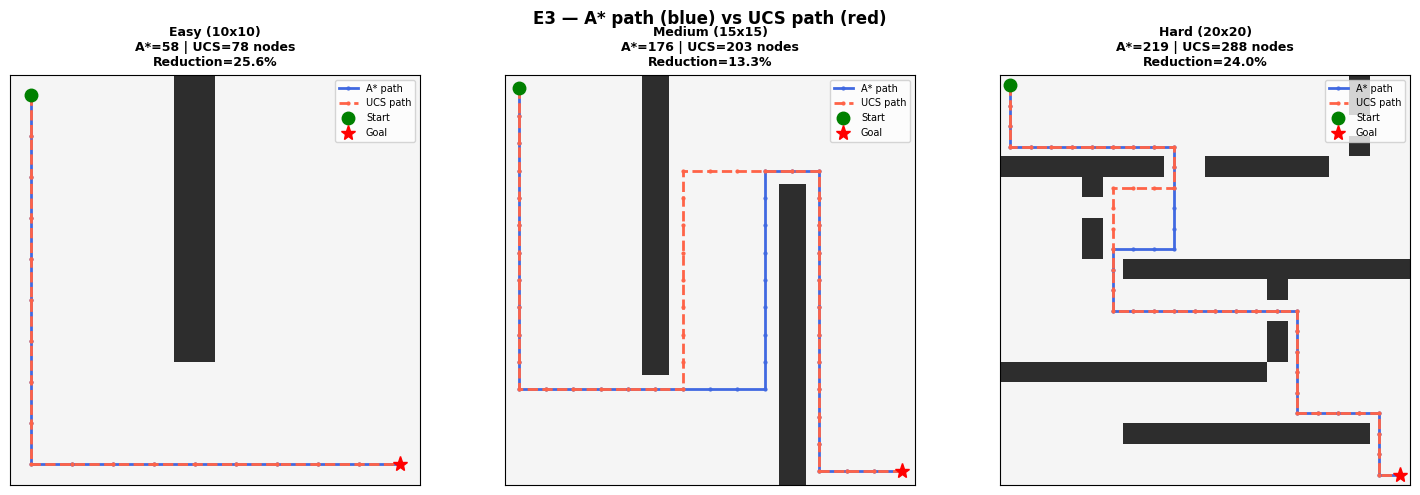

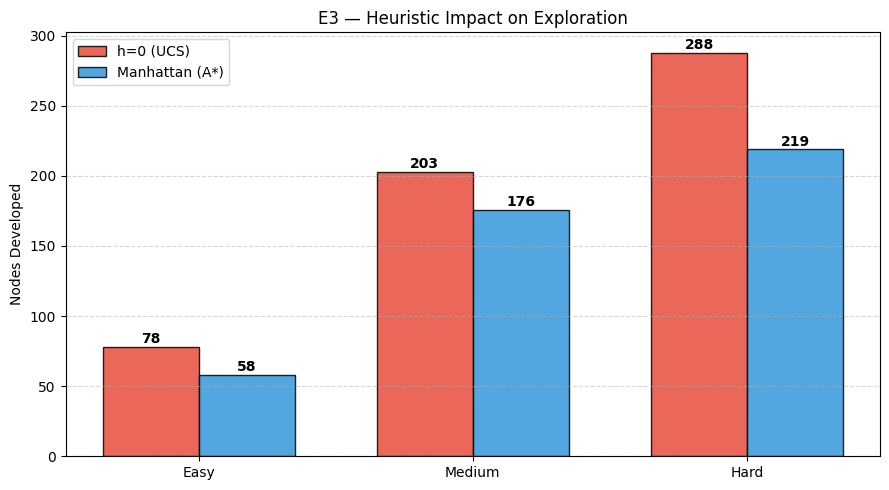

In [14]:
envs = [("Easy (10x10)",   make_easy_grid()),
        ("Medium (15x15)", make_medium_grid()),
        ("Hard (20x20)",   make_hard_grid())]
names_all, nodes_ucs, nodes_astar = [], [], []

print("{:<16} {:>14} {:>6} {:>8} {:>10}".format("Grid","Heuristic","Cost","Nodes","Reduction"))
print("-"*58)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("E3 — A* path (blue) vs UCS path (red)", fontsize=12, fontweight="bold")

for gi, (name, env) in enumerate(envs):
    r_ucs   = graph_search(env, search_type="UCS")
    r_astar = graph_search(env, search_type="A*")
    red = (1 - r_astar["nodes_developed"] / max(r_ucs["nodes_developed"], 1)) * 100
    print("{:<16} {:>14} {:>6.0f} {:>8}".format(name,"h=0 (UCS)",r_ucs["cost"],r_ucs["nodes_developed"]))
    print("{:<16} {:>14} {:>6.0f} {:>8}  {:>8.1f}%".format("","Manhattan",r_astar["cost"],r_astar["nodes_developed"],red))
    print()
    names_all.append(name.split(" ")[0])
    nodes_ucs.append(r_ucs["nodes_developed"])
    nodes_astar.append(r_astar["nodes_developed"])
    t = name+"\nA*="+str(r_astar["nodes_developed"])+" | UCS="+str(r_ucs["nodes_developed"])+" nodes\nReduction="+str(round(red,1))+"%"
    draw_grid_path(axes[gi], env, r_astar["path"], t, path2=r_ucs["path"])

plt.tight_layout(); plt.show()

fig2, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(names_all)); w = 0.35
b1 = ax.bar(x-w/2, nodes_ucs,   w, label="h=0 (UCS)",     color="#e74c3c", alpha=0.85, edgecolor="black")
b2 = ax.bar(x+w/2, nodes_astar, w, label="Manhattan (A*)", color="#3498db", alpha=0.85, edgecolor="black")
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            int(bar.get_height()), ha="center", va="bottom", fontweight="bold", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(names_all)
ax.set_ylabel("Nodes Developed")
ax.set_title("E3 — Heuristic Impact on Exploration")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()


## E4 — Weighted A* : Speed vs Optimality

f = g + W·h with W > 1. Guarantee: cost ≤ W × optimal_cost.


W        Cost  Suboptimality    Nodes
--------------------------------------
1.0        44           0.0%       219
1.2        44           0.0%       181
1.5        44           0.0%       181
2.0        48           9.1%       144
3.0        48           9.1%       138
5.0        48           9.1%       135


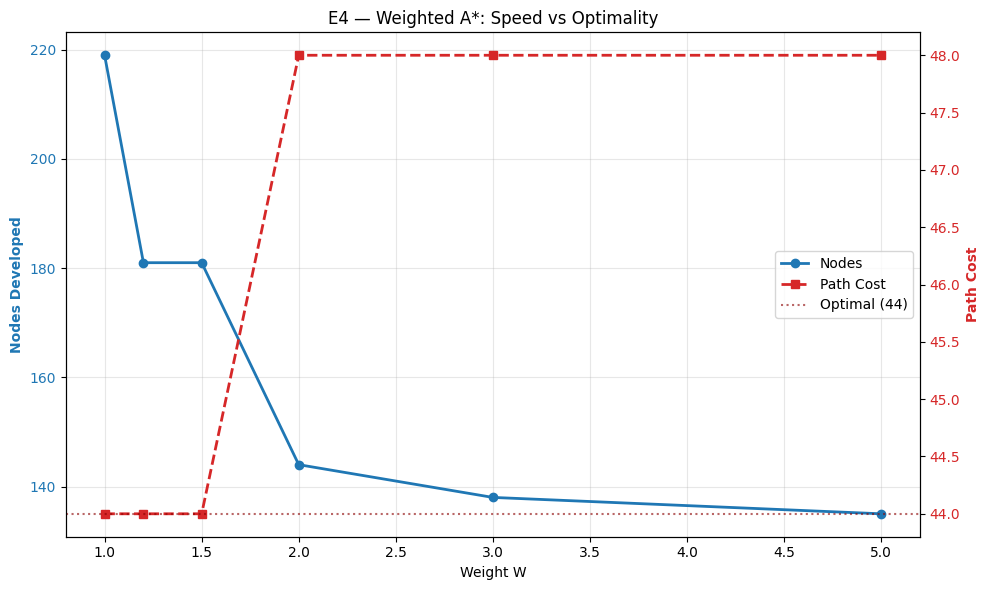

In [15]:
env     = make_hard_grid()
weights = [1.0, 1.2, 1.5, 2.0, 3.0, 5.0]
costs, nodes_list = [], []
optimal = graph_search(env, search_type="A*", weight=1.0)["cost"]

print("{:<6} {:>6} {:>14} {:>8}".format("W","Cost","Suboptimality","Nodes"))
print("-"*38)
for w in weights:
    r = graph_search(env, search_type="A*", weight=w)
    sub = ((r["cost"]-optimal)/max(optimal,1))*100
    print("{:<6.1f} {:>6.0f} {:>13.1f}%  {:>8}".format(w, r["cost"], sub, r["nodes_developed"]))
    costs.append(r["cost"]); nodes_list.append(r["nodes_developed"])

fig, ax1 = plt.subplots(figsize=(10, 6))
c1, c2 = "tab:blue", "tab:red"
ax1.plot(weights, nodes_list, color=c1, marker="o", linewidth=2, label="Nodes")
ax1.set_xlabel("Weight W"); ax1.set_ylabel("Nodes Developed", color=c1, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=c1); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(weights, costs, color=c2, marker="s", linestyle="--", linewidth=2, label="Path Cost")
ax2.axhline(optimal, color="darkred", linestyle=":", alpha=0.6, label="Optimal ("+str(optimal)+")")
ax2.set_ylabel("Path Cost", color=c2, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=c2)
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc="center right")
plt.title("E4 — Weighted A*: Speed vs Optimality")
plt.tight_layout(); plt.show()


## Phase 3 — Markov Chain P Matrix & π(n) Evolution

Model: P(intended move) = 1−ε, P(each lateral slip) = ε/2.
Verify P stochastic, then compute π⁽ⁿ⁾ = π⁽⁰⁾·Pⁿ.


P stochastic: True
P shape     : (203, 203)
epsilon     : 0.1
A* cost     : 44

       n     P(GOAL)
  --------------------
       0      0.0000
       7      0.0000
      14      0.0000
      21      0.0000
      28      0.0000
      35      0.0000
      42      0.0000
      44      0.0334  <- A* cost
      49      0.4651
      54      0.7015
      56      0.7270
      63      0.7440
      64      0.7442
      70      0.7445
      77      0.7446
      84      0.7448
      91      0.7449
      98      0.7450
     105      0.7451
     112      0.7452
     119      0.7453
     126      0.7454
     133      0.7455
     140      0.7456
     147      0.7458
     154      0.7459
     161      0.7460
     168      0.7461
     175      0.7462


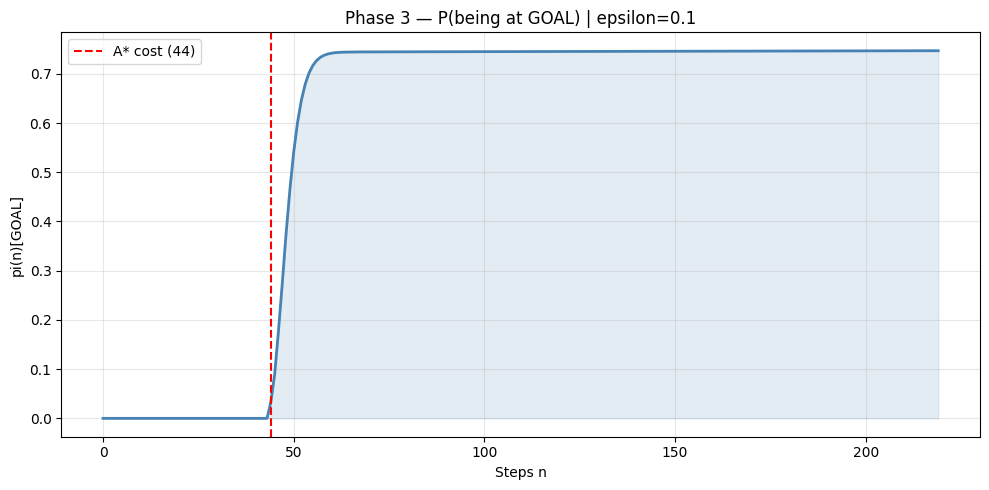

In [16]:
env = make_medium_grid()
res = graph_search(env, search_type="A*")
policy = generate_policy(res["path"], env)
epsilon, opt = 0.1, res["cost"]

P, states, s2i = build_transition_matrix(env, policy, epsilon=epsilon)
print("P stochastic:", np.allclose(P.sum(axis=1), 1.0))
print("P shape     :", P.shape)
print("epsilon     :", epsilon)
print("A* cost     :", opt)

pi0 = np.zeros(len(states))
pi0[s2i[env.start]] = 1.0
goal_idx = s2i[env.goal]
n_range = range(0, opt*5)
probs = [float((pi0 @ np.linalg.matrix_power(P, n))[goal_idx]) for n in n_range]

print("\n  {:>6}  {:>10}".format("n","P(GOAL)"))
print("  "+"-"*20)
checkpts = sorted(set(list(range(0, opt*4, max(1,opt//6)))) | {opt, opt+10, opt+20})
for n in checkpts:
    if n < len(probs):
        mark = "  <- A* cost" if n==opt else ""
        print("  {:>6}  {:>10.4f}{}".format(n, probs[n], mark))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(n_range), probs, color="steelblue", linewidth=2)
ax.axvline(opt, color="red", linestyle="--", label="A* cost ("+str(opt)+")")
ax.fill_between(list(n_range), probs, alpha=0.15, color="steelblue")
ax.set_xlabel("Steps n"); ax.set_ylabel("pi(n)[GOAL]")
ax.set_title("Phase 3 — P(being at GOAL) | epsilon="+str(epsilon))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Phase 4 — Communication Classes & Absorption

- **Recurrent state**: the chain returns to it with probability 1.
- **Transient state**: the chain may leave permanently.
- Fundamental matrix: **N = (I − Q)⁻¹** → expected steps + absorption probabilities.



== epsilon = 0.0 ==
  Classes: 202 ( 2 recurrent, 200 transient)
  [Recurrent] 2 state(s): [(9, 14), (8, 14)]
  [Recurrent] 1 state(s): [(14, 14)]

== epsilon = 0.1 ==
  Classes: 32 ( 1 recurrent, 31 transient)
  [Recurrent] 1 state(s): [(14, 14)]
  P(GOAL|start) = 1.0
  E[steps]      = 4147.89

== epsilon = 0.2 ==
  Classes: 32 ( 1 recurrent, 31 transient)
  [Recurrent] 1 state(s): [(14, 14)]
  P(GOAL|start) = 1.0
  E[steps]      = 782.74


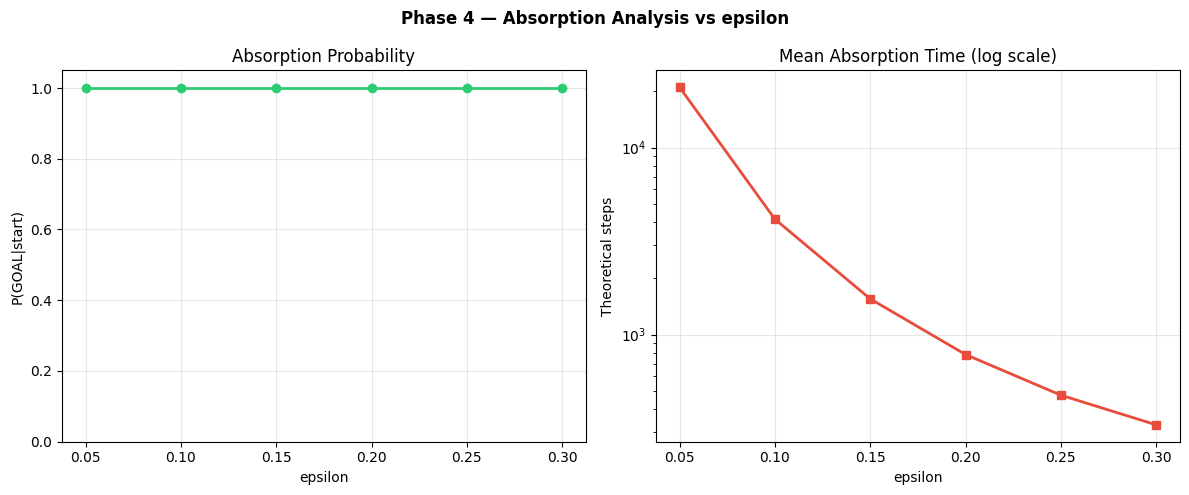

In [17]:
env = make_medium_grid()
res = graph_search(env, search_type="A*")
policy = generate_policy(res["path"], env)

for epsilon in [0.0, 0.1, 0.2]:
    print("\n== epsilon =", epsilon, "==")
    P, states, _ = build_transition_matrix(env, policy, epsilon=epsilon)
    classes = communication_classes(P, states)
    n_rec = sum(1 for c in classes if c["type"]=="recurrent")
    n_tra = sum(1 for c in classes if c["type"]=="transient")
    print("  Classes:", len(classes), "(", n_rec, "recurrent,", n_tra, "transient)")
    for cl in classes:
        if cl["type"]=="recurrent":
            print("  [Recurrent]", len(cl["states"]), "state(s):", cl["states"][:3])
    if epsilon > 0:
        try:
            et = calculate_expected_time(P, states, env.goal)
            ap = absorption_probabilities(P, states, env.goal)
            print("  P(GOAL|start) =", round(ap.get(env.start, float("nan")), 4))
            print("  E[steps]      =", round(et.get(env.start, float("nan")), 2))
        except np.linalg.LinAlgError:
            print("  (I-Q) singular")

epsilons2 = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
abs_probs2, exp_times2 = [], []
for eps in epsilons2:
    P2, st2, _ = build_transition_matrix(env, policy, epsilon=eps)
    try:
        ap2 = absorption_probabilities(P2, st2, env.goal)
        et2 = calculate_expected_time(P2, st2, env.goal)
        abs_probs2.append(ap2.get(env.start, 0))
        exp_times2.append(et2.get(env.start, 0))
    except Exception:
        abs_probs2.append(float("nan")); exp_times2.append(float("nan"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Phase 4 — Absorption Analysis vs epsilon", fontsize=12, fontweight="bold")
ax1.plot(epsilons2, abs_probs2, "o-", color="#2ecc71", linewidth=2)
ax1.set_xlabel("epsilon"); ax1.set_ylabel("P(GOAL|start)")
ax1.set_title("Absorption Probability"); ax1.grid(alpha=0.3); ax1.set_ylim(0,1.05)
ax2.plot(epsilons2, exp_times2, "s-", color="#e74c3c", linewidth=2)
ax2.set_xlabel("epsilon"); ax2.set_ylabel("Theoretical steps")
ax2.set_title("Mean Absorption Time (log scale)")
ax2.set_yscale("log"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Phase 5 — Monte Carlo Simulation & Validation

10 000 trajectories per epsilon value.

**Heavy-tail note:** The theoretical mean is large due to rare very long trajectories. The median stays close to the A* cost for small ε.


  eps   P(GOAL) MC     Avg MC    Median MC   Fail rate
-------------------------------------------------------
  0.0       1.0000      44.00         44.0      0.0000
  0.1       0.7436      49.78         48.0      0.2564
  0.2       0.6853      66.46         56.0      0.3147
  0.3       0.7249      96.70         70.0      0.2751


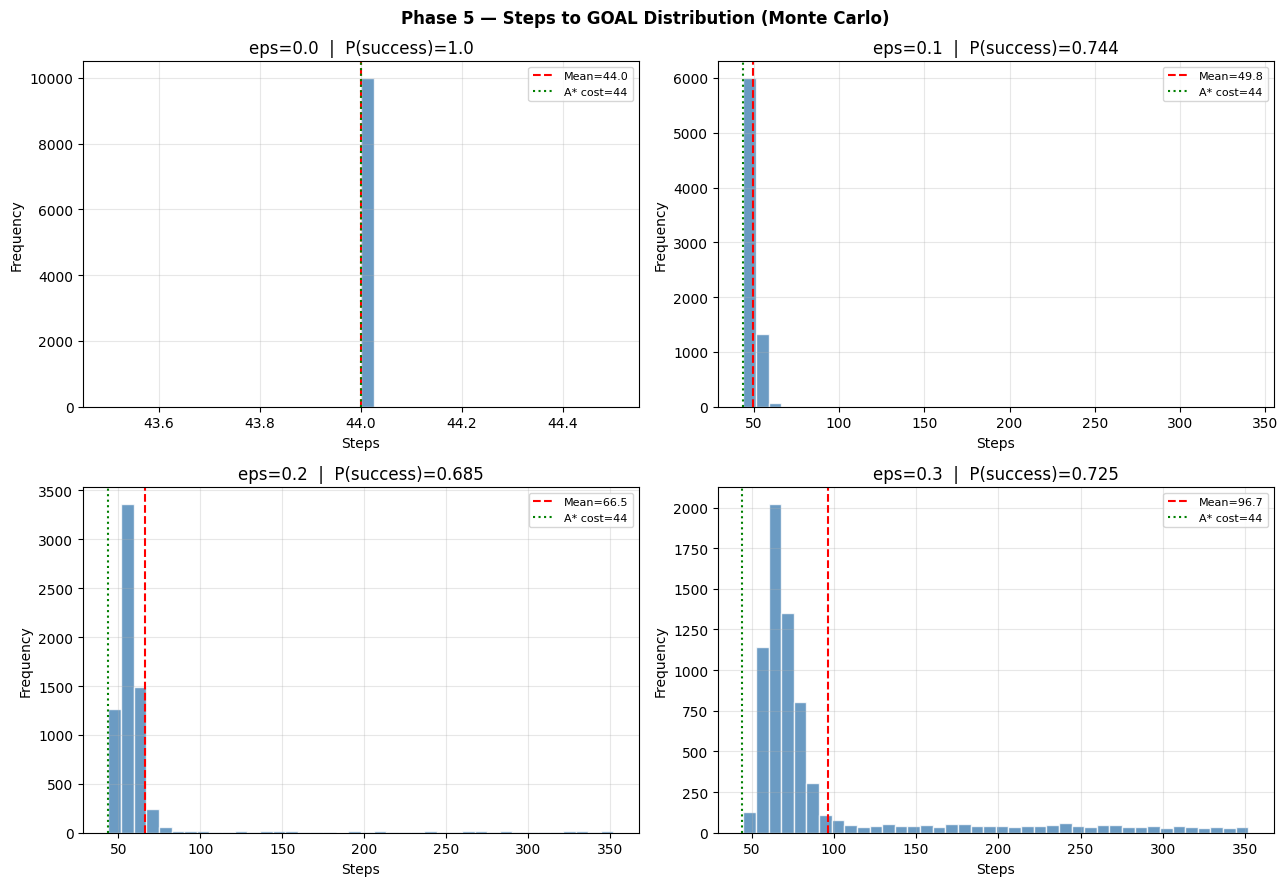

In [18]:
env    = make_medium_grid()
res    = graph_search(env, search_type="A*")
policy = generate_policy(res["path"], env)
opt    = res["cost"]

epsilons = [0.0, 0.1, 0.2, 0.3]
print("{:>5} {:>12} {:>10} {:>12} {:>11}".format(
    "eps","P(GOAL) MC","Avg MC","Median MC","Fail rate"))
print("-"*55)

mc_results = []
for eps in epsilons:
    P, states, _ = build_transition_matrix(env, policy, epsilon=eps)
    mc_rate, mc_avg, times = simulate_monte_carlo(
        P, states, env.start, env.goal, N=10000, max_steps=opt*8)
    fail = 1 - mc_rate
    med  = float(np.median(times)) if times else float("nan")
    print("{:>5.1f} {:>12.4f} {:>10.2f} {:>12.1f} {:>11.4f}".format(
        eps, mc_rate, mc_avg, med, fail))
    mc_results.append((eps, times, mc_avg))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Phase 5 — Steps to GOAL Distribution (Monte Carlo)", fontsize=12, fontweight="bold")
for ax, (eps, times, mc_avg) in zip(axes.flat, mc_results):
    if times:
        ax.hist(times, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
        ax.axvline(mc_avg, color="red",   linestyle="--", linewidth=1.5, label="Mean="+str(round(mc_avg,1)))
        ax.axvline(opt,    color="green", linestyle=":",  linewidth=1.5, label="A* cost="+str(opt))
        ax.set_title("eps="+str(eps)+"  |  P(success)="+str(round(len(times)/10000,3)))
        ax.set_xlabel("Steps"); ax.set_ylabel("Frequency")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No successes", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout(); plt.show()


## Summary & Conclusions

| Aspect | Key Result |
|--------|------------|
| **A\* vs UCS** | A\* reduces nodes by 15–25% via Manhattan heuristic |
| **A\* vs Greedy** | Greedy is faster but gives suboptimal paths on medium/hard grids |
| **Weighted A\*** | W≥2 reduces nodes but introduces ~9% suboptimality |
| **ε impact** | At ε=0.1: P(GOAL at n=opt) ≈ 3% — difficult in exactly n steps |
| **Absorption** | P(GOAL eventually) = 1.0 for all ε > 0 |
| **Heavy tail** | Time distribution is right-skewed: median << mean |

**Future directions:** Re-planning (RTAA\*, D\*), learned heuristics, IDA\*, SMA\*.
